In [60]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction import DictVectorizer
from sklearn.model_selection import train_test_split
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [5]:
df=pd.read_csv("https://raw.githubusercontent.com/brunobro/dataset-forty-soybean-cultivars-from-subsequent-harvests/refs/heads/main/data.csv")

In [6]:
df.head()

,Season,Cultivar,Repetition,PH,IFP,NLP,NGP,NGL,NS,MHG,GY
0,1,NEO 760 CE,1,58.80,15.20,98.2,177.80,1.81,5.2,152.20,3232.82
1,1,NEO 760 CE,2,58.60,13.40,102.0,195.00,1.85,7.2,141.69,3517.36
2,1,NEO 760 CE,3,63.40,17.20,100.4,203.00,2.02,6.8,148.81,3391.46
3,1,NEO 760 CE,4,60.27,15.27,100.2,191.93,1.89,6.4,148.50,3312.58
4,1,MANU IPRO,1,81.20,18.00,98.8,173.00,1.75,7.4,145.59,3230.99


## Convert the Cultivar to lowercase then vectorize

In [13]:
df['Cultivar'] = df['Cultivar'].str.lower().str.replace(r'\s+', '_', regex=True).str.strip()

In [14]:
df.head()

,Season,Cultivar,Repetition,PH,IFP,NLP,NGP,NGL,NS,MHG,GY
0,1,neo_760_ce,1,58.80,15.20,98.2,177.80,1.81,5.2,152.20,3232.82
1,1,neo_760_ce,2,58.60,13.40,102.0,195.00,1.85,7.2,141.69,3517.36
2,1,neo_760_ce,3,63.40,17.20,100.4,203.00,2.02,6.8,148.81,3391.46
3,1,neo_760_ce,4,60.27,15.27,100.2,191.93,1.89,6.4,148.50,3312.58
4,1,manu_ipro,1,81.20,18.00,98.8,173.00,1.75,7.4,145.59,3230.99


In [15]:
print(df['Cultivar'].unique())

['neo_760_ce' 'manu_ipro' '77ho111i2x_-_guaporé' 'nk_7777_ipro'
 'gns7900_ipro_-_ampla' 'ltt_7901_ipro' 'brasmax_bônus_ipro' '97y97_ipro'
 'brasmax_olimpo_ipro' 'lynda_ipro' 'nk_8100_ipro'
 '82ho111_ipro_-_ho_coxim_ipro' '83ix84rsf_i2x' 'adapta_ltt_8402_ipro'
 '98r30_ce' 'fortaleza_ipro' 'monsoy_8330i2x' 'suzy_ipro' 'tmg_22x83i2x'
 'expande_ltt_8301_ipro' 'fortalece_l090183_rr' '96r29_ipro' '74k75rsf_ce'
 'ftr_3868_ipro' 'gns7700_ipro' 'elisa_ipro' '79i81rsf_ipro'
 'neo_790_ipro' 'paula_ipro' 'ftr_3179_ipro' 'lat_1330bt' 'ftr_4280_ipro'
 'ataque_i2x' 'syn2282ipro' '82i78rsf_ipro' 'm_8644_ipro'
 'monsoy_m8606i2x' 'nk_8770_ipro' 'ftr_4288_ipro' 'ftr_3190_ipro']


In [58]:
print("1. DATASET OVERVIEW")
print("="*80)

print(f"\nDataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nFirst 5 rows:")
print(df.head())

print(f"\nData Types:")
print(df.dtypes)

print(f"\nMissing Values:")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("No missing values!")

print(f"\nUnique Cultivars: {df['Cultivar'].nunique()}")
print(f"Seasons: {df['Season'].unique()}")

1. DATASET OVERVIEW

Dataset Shape: 320 rows × 11 columns

First 5 rows:
   Season    Cultivar  Repetition     PH    IFP    NLP     NGP   NGL   NS  \
0       1  neo_760_ce           1  58.80  15.20   98.2  177.80  1.81  5.2   
1       1  neo_760_ce           2  58.60  13.40  102.0  195.00  1.85  7.2   
2       1  neo_760_ce           3  63.40  17.20  100.4  203.00  2.02  6.8   
3       1  neo_760_ce           4  60.27  15.27  100.2  191.93  1.89  6.4   
4       1   manu_ipro           1  81.20  18.00   98.8  173.00  1.75  7.4   

      MHG       GY  
0  152.20  3232.82  
1  141.69  3517.36  
2  148.81  3391.46  
3  148.50  3312.58  
4  145.59  3230.99  

Data Types:
Season          int64
Cultivar       object
Repetition      int64
PH            float64
IFP           float64
NLP           float64
NGP           float64
NGL           float64
NS            float64
MHG           float64
GY            float64
dtype: object

Missing Values:
No missing values!

Unique Cultivars: 40
Seasons: [1

In [57]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumeric columns: {len(numeric_cols)}")
print(df[numeric_cols].describe().T)


Numeric columns: 10
            count         mean         std      min          25%          50%  \
Season      320.0     1.500000    0.500783     1.00     1.000000     1.500000   
Repetition  320.0     2.500000    1.119785     1.00     1.750000     2.500000   
PH          320.0    68.386781    8.958194    47.60    62.950000    67.200000   
IFP         320.0    15.465000    3.024300     7.20    13.600000    15.600000   
NLP         320.0    59.088313   20.068187    20.20    44.350000    54.500000   
NGP         320.0   135.085844   60.494529    47.80    95.052500   123.000000   
NGL         320.0     2.290844    0.840116     0.94     2.000000     2.280000   
NS          320.0     4.071656    1.474531     0.40     3.000000     3.800000   
MHG         320.0   168.322313   19.625566   127.06   153.845000   166.150000   
GY          320.0  3418.553794  503.003602  1538.23  3126.611552  3397.276724   

                    75%      max  
Season         2.000000     2.00  
Repetition     3.

Text(0.5, 1.0, 'Correlation Matrix Heatmap - All Numeric Variables')

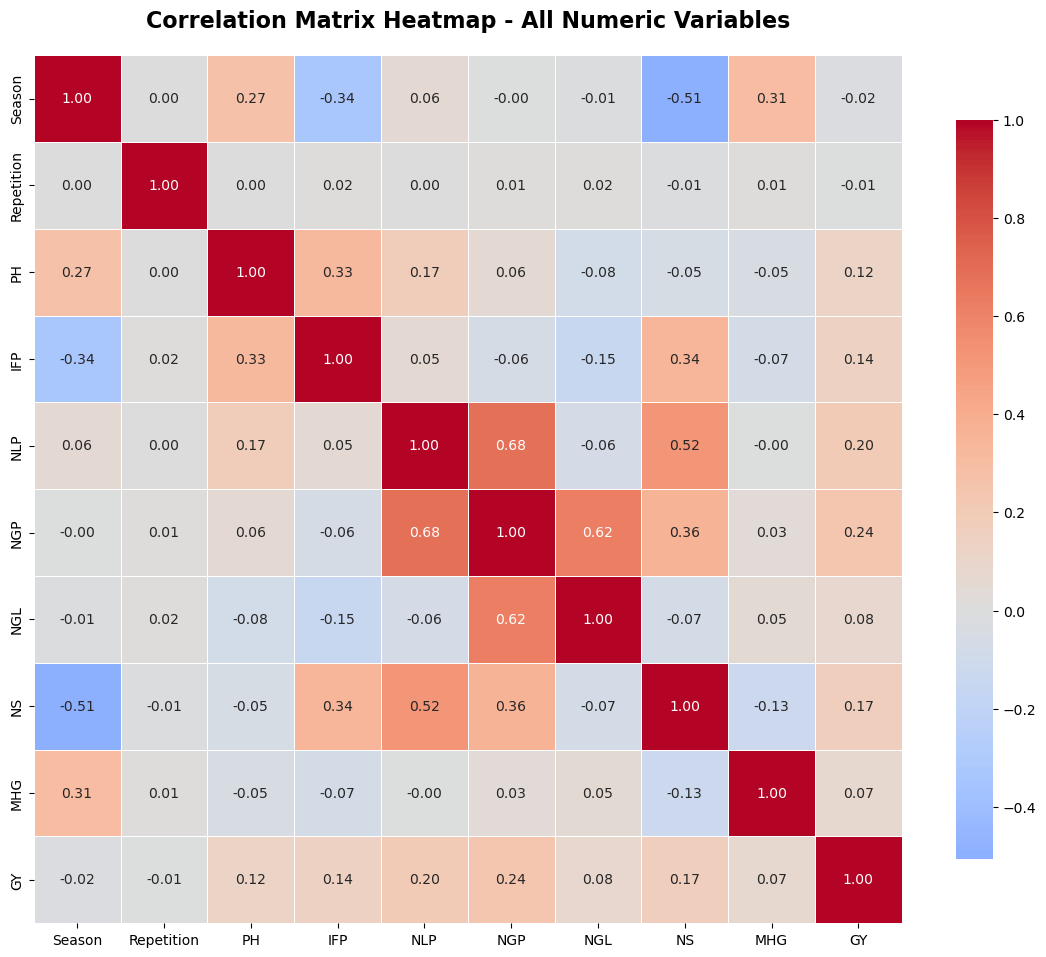

In [62]:
corr_matrix = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, 
            cbar_kws={"shrink": 0.8}, ax=ax)
plt.title('Correlation Matrix Heatmap - All Numeric Variables', 
          fontsize=16, fontweight='bold', pad=20)

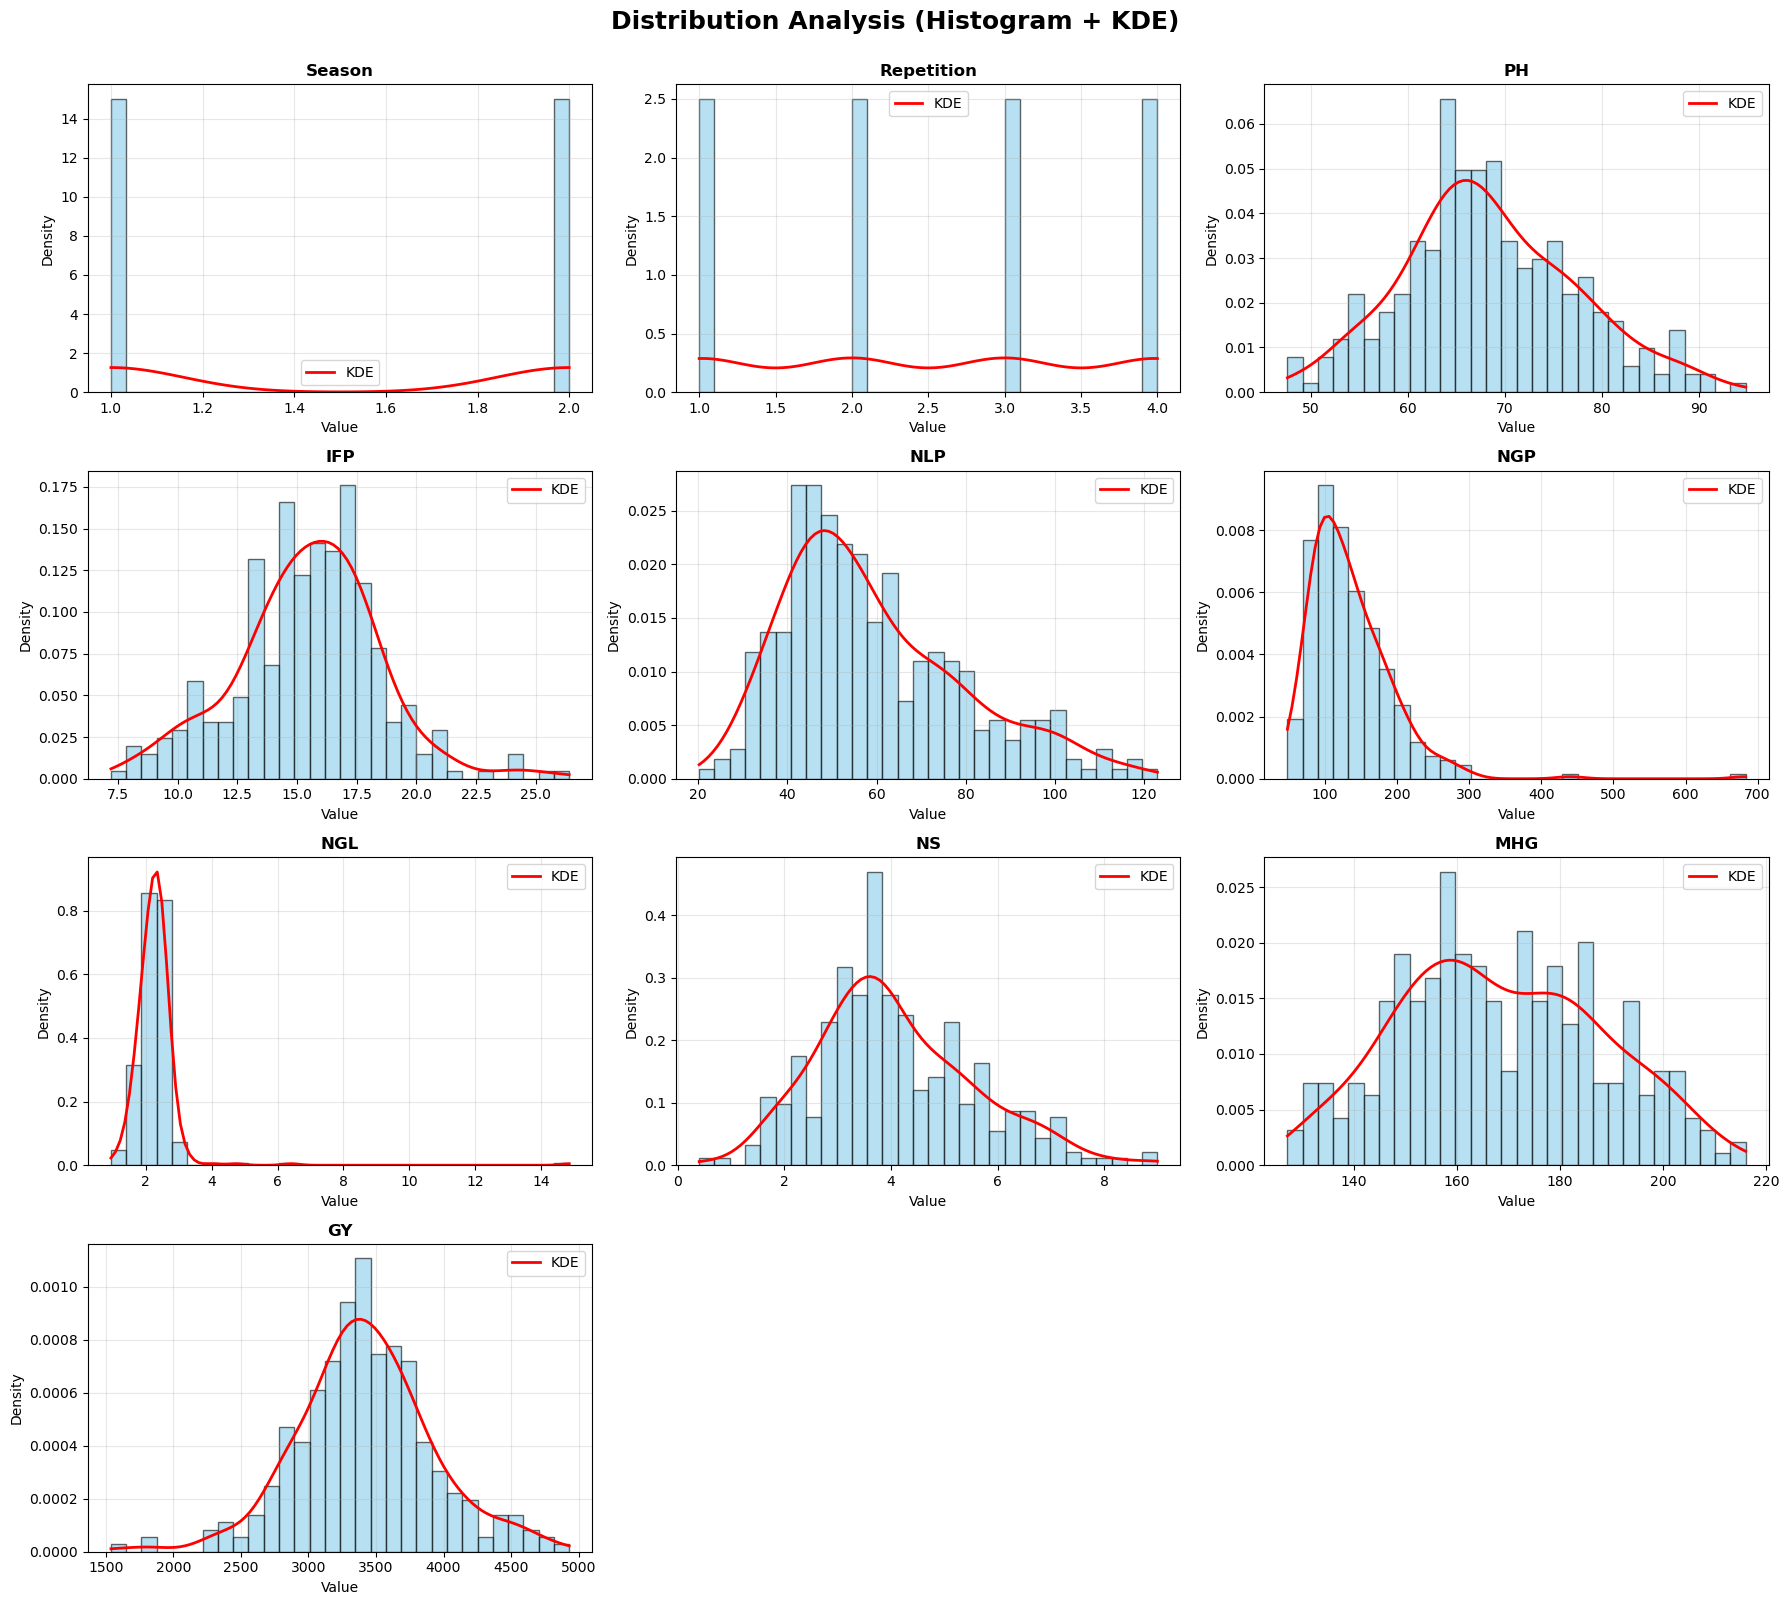

In [63]:
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*4))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    data = df[col].dropna()
    
    # Histogram
    ax.hist(data, bins=30, alpha=0.6, color='skyblue', edgecolor='black', density=True)
    
    # KDE
    try:
        kde = stats.gaussian_kde(data)
        x_range = np.linspace(data.min(), data.max(), 100)
        ax.plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')
    except:
        pass
    
    ax.set_title(f'{col}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Value', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend()
    ax.grid(alpha=0.3)

# Remove empty subplots
for idx in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Distribution Analysis (Histogram + KDE)', 
             fontsize=18, fontweight='bold', y=1.00)
plt.tight_layout()

Text(0.5, 1.0, 'Scatter Plots - Variable Pairs')

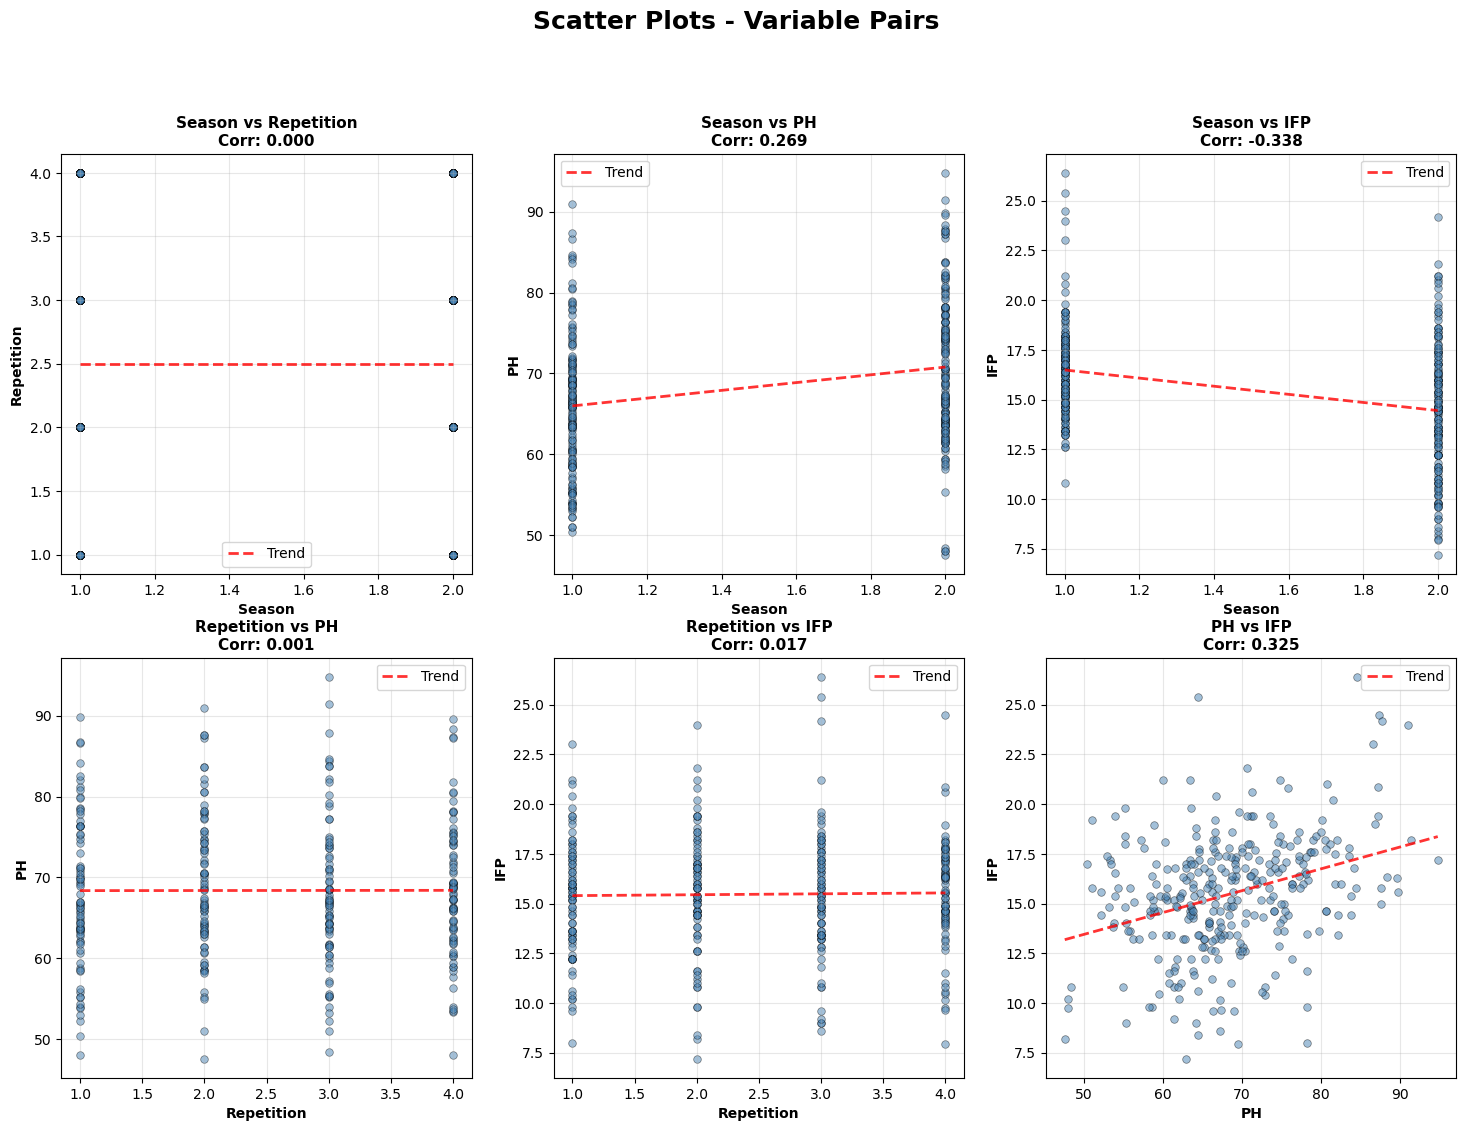

In [66]:
vars_to_plot = numeric_cols[:min(4, len(numeric_cols))]  # First 4 variables

# Create all possible pairs
pairs_to_plot = []
for i in range(len(vars_to_plot)):
    for j in range(i+1, len(vars_to_plot)):
        pairs_to_plot.append((vars_to_plot[i], vars_to_plot[j]))

# Plot first 6 pairs (or fewer if not enough)
n_plots = min(6, len(pairs_to_plot))
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx in range(n_plots):
    ax = axes[idx]
    var1, var2 = pairs_to_plot[idx]
    
    # Get correlation value
    corr_val = corr_matrix.loc[var1, var2]
    
    # Create scatter plot
    ax.scatter(df[var1], df[var2], 
               alpha=0.5, 
               s=30, 
               color='steelblue', 
               edgecolors='black', 
               linewidth=0.5)
    
    ax.set_xlabel(var1, fontsize=10, fontweight='bold')
    ax.set_ylabel(var2, fontsize=10, fontweight='bold')
    ax.set_title(f'{var1} vs {var2}\nCorr: {corr_val:.3f}', 
                 fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3)
    
    # Add trend line
    try:
        clean_data = df[[var1, var2]].dropna()
        z = np.polyfit(clean_data[var1], clean_data[var2], 1)
        p = np.poly1d(z)
        x_sorted = clean_data[var1].sort_values()
        ax.plot(x_sorted, p(x_sorted), 
                "r--", alpha=0.8, linewidth=2, label='Trend')
        ax.legend()
    except:
        pass

# Remove empty subplots
for idx in range(n_plots, len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Scatter Plots - Variable Pairs', 
             fontsize=18, fontweight='bold', y=1.00)

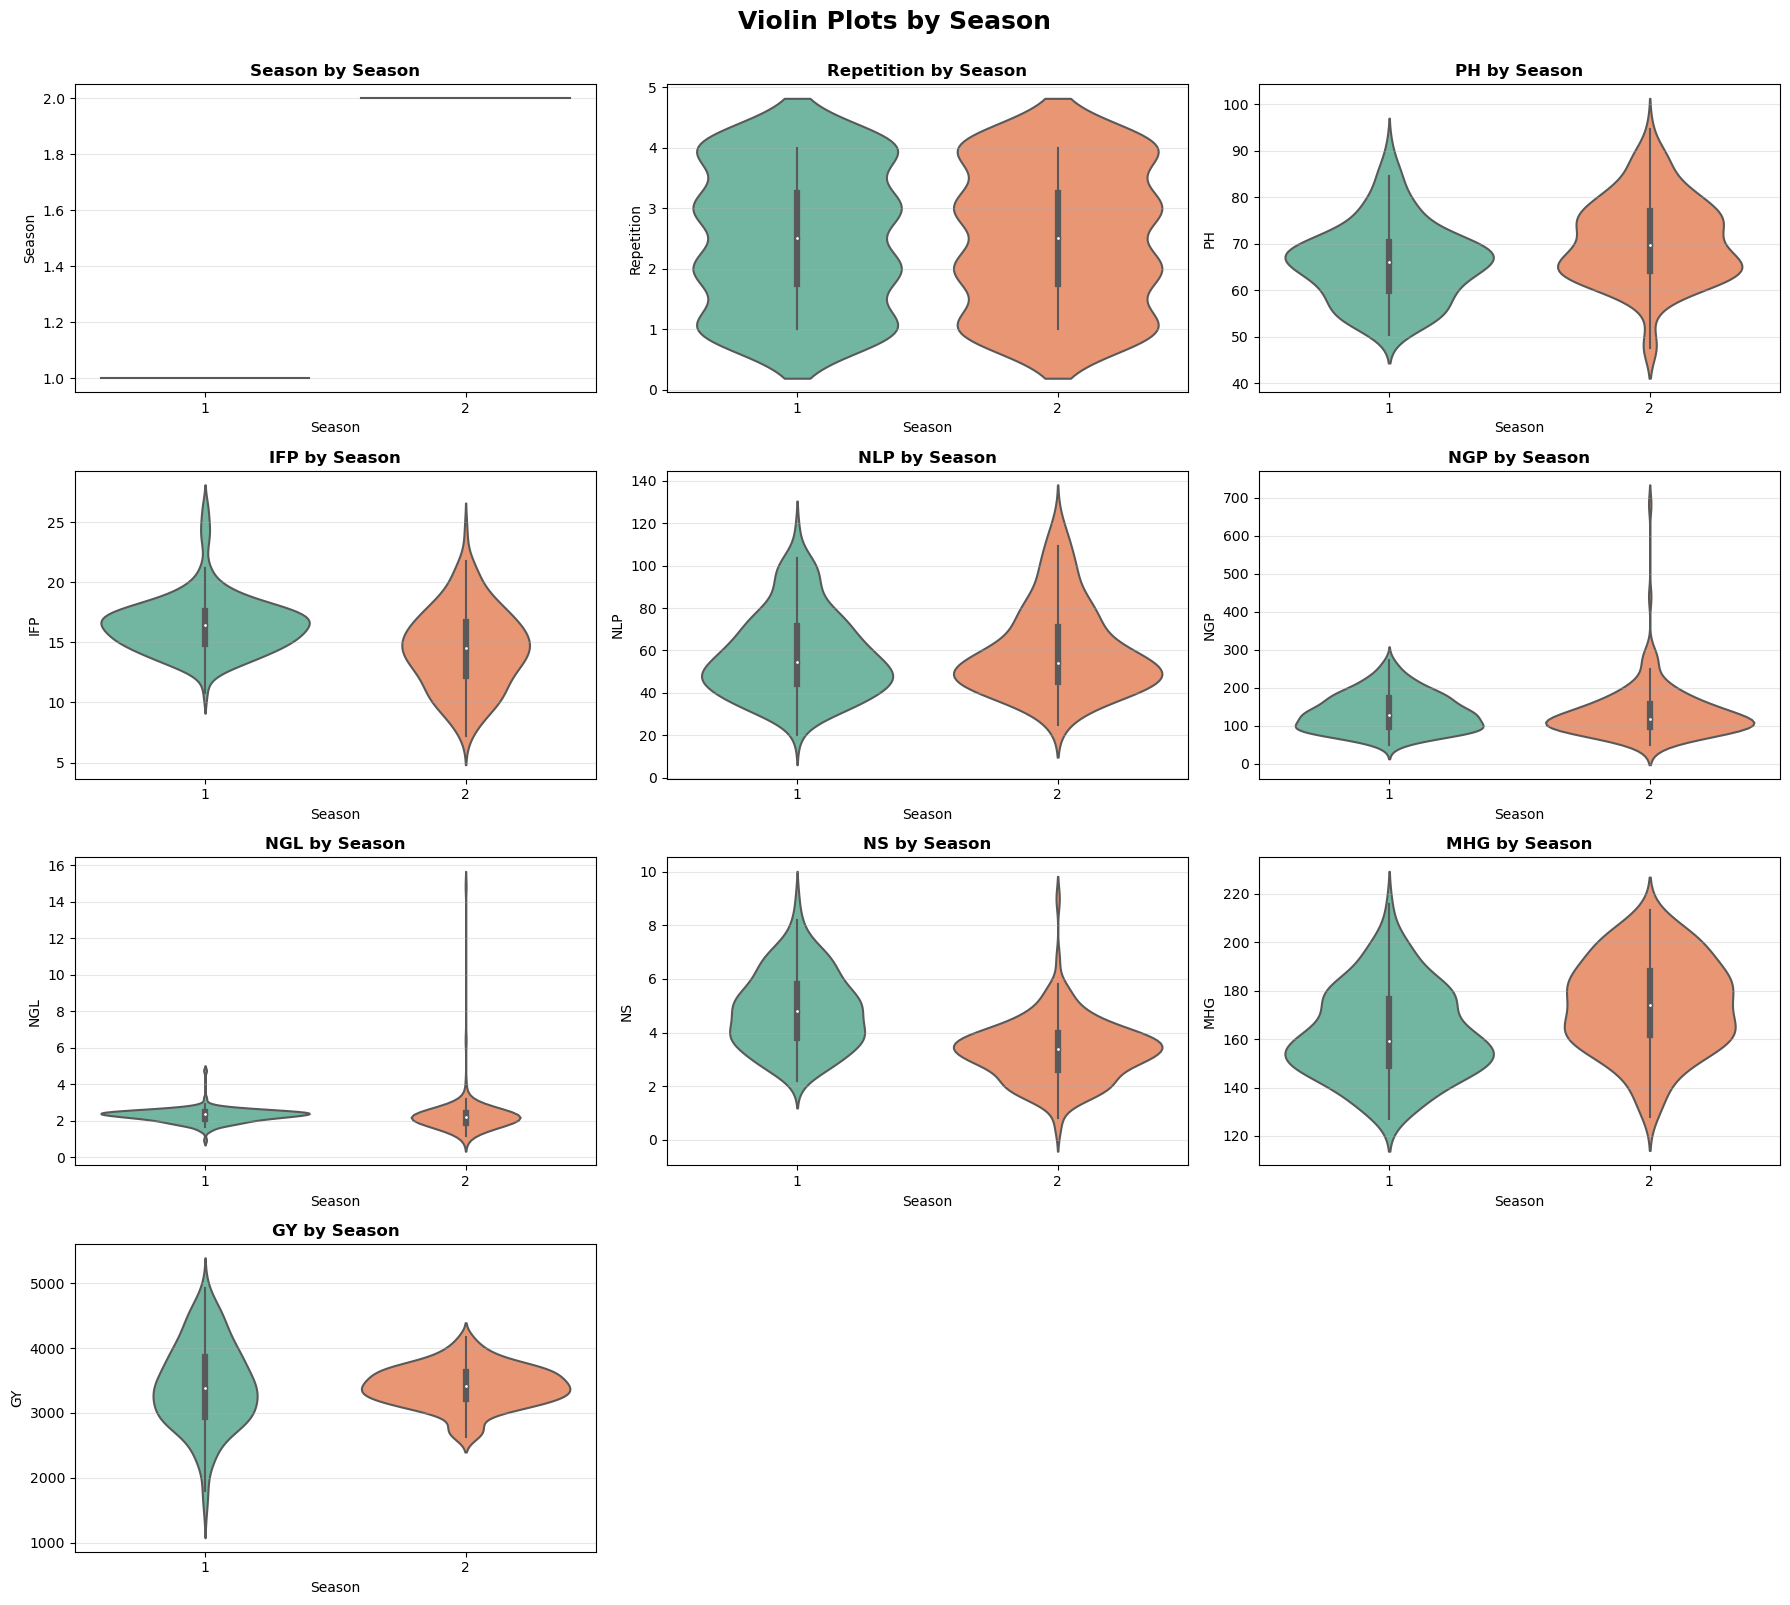

In [67]:
if 'Season' in df.columns:
    n_cols = 3
    n_rows = int(np.ceil(len(numeric_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*4))
    axes = axes.flatten()
    
    for idx, col in enumerate(numeric_cols):
        ax = axes[idx]
        sns.violinplot(data=df, x='Season', y=col, ax=ax, palette='Set2')
        ax.set_title(f'{col} by Season', fontsize=12, fontweight='bold')
        ax.set_xlabel('Season', fontsize=10)
        ax.set_ylabel(col, fontsize=10)
        ax.grid(alpha=0.3, axis='y')
    
    # Remove empty subplots
    for idx in range(len(numeric_cols), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.suptitle('Violin Plots by Season', 
                 fontsize=18, fontweight='bold', y=1.00)
    plt.tight_layout()


Generating pair plot...
Creating pairplot for: ['PH', 'IFP', 'NLP', 'NGP', 'NGL']


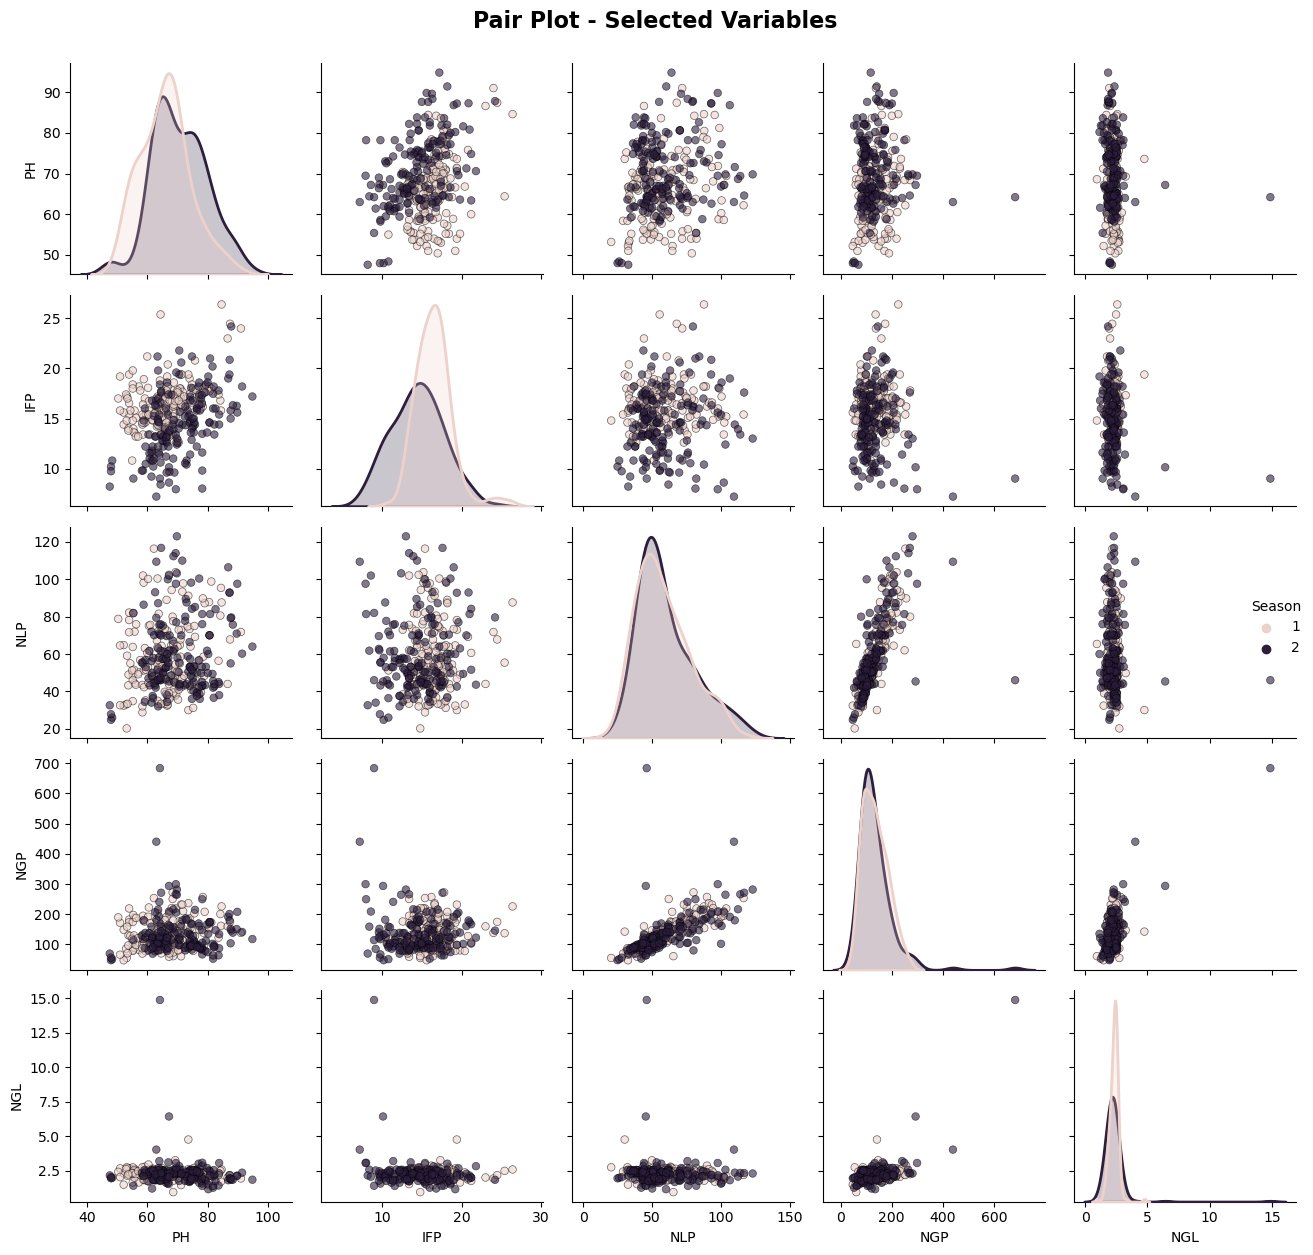

In [80]:
# ==============================================================================
# 5. PAIR PLOT
# ==============================================================================
print("\nGenerating pair plot...")

# Pick first 5 NUMERIC variables only (excluding Season)
# Filter out 'Season' from numeric_cols first
numeric_only = [col for col in numeric_cols if col not in ['Season', 'Cultivar', 'Repetition']]

# Now select first 5
pairplot_vars = numeric_only[:5]
print(f"Creating pairplot for: {pairplot_vars}")

# Create dataframe with selected numeric variables + Season for coloring
pairplot_df = df[pairplot_vars + ['Season']].copy()

# Create the pair plot
g = sns.pairplot(
    pairplot_df, 
    hue='Season',                    # Color by season
    diag_kind='kde',                 # Smooth curves on diagonal
    plot_kws={                       # Settings for scatter plots
        'alpha': 0.6,                # Transparency
        's': 30,                     # Point size
        'edgecolor': 'k',            # Black outline
        'linewidth': 0.5             # Thin outline
    },
    diag_kws={'linewidth': 2}        # Thick line for KDE curves
)

# Add main title
g.fig.suptitle('Pair Plot - Selected Variables', 
               fontsize=16, 
               fontweight='bold', 
               y=1.00)

plt.tight_layout()
plt.show()

In [21]:
x=df.drop('GY',axis=1)
y=df["GY"]

In [23]:
x.head()

,Season,Cultivar,Repetition,PH,IFP,NLP,NGP,NGL,NS,MHG
0,1,neo_760_ce,1,58.80,15.20,98.2,177.80,1.81,5.2,152.20
1,1,neo_760_ce,2,58.60,13.40,102.0,195.00,1.85,7.2,141.69
2,1,neo_760_ce,3,63.40,17.20,100.4,203.00,2.02,6.8,148.81
3,1,neo_760_ce,4,60.27,15.27,100.2,191.93,1.89,6.4,148.50
4,1,manu_ipro,1,81.20,18.00,98.8,173.00,1.75,7.4,145.59


In [25]:
# Convert X to list of dictionaries
X_dicts = x.to_dict('records')
# Initialize and fit DictVectorizer
dv = DictVectorizer(sparse=False)
X_vectorized = dv.fit_transform(X_dicts)

In [27]:
print(f"Original X shape: {x.shape}")
print(f"Vectorized X shape: {X_vectorized.shape}")
print(f"\nFeature names ({len(dv.get_feature_names_out())} total):")
print(dv.get_feature_names_out())

Original X shape: (320, 10)
Vectorized X shape: (320, 49)

Feature names (49 total):
['Cultivar=74k75rsf_ce' 'Cultivar=77ho111i2x_-_guaporé'
 'Cultivar=79i81rsf_ipro' 'Cultivar=82ho111_ipro_-_ho_coxim_ipro'
 'Cultivar=82i78rsf_ipro' 'Cultivar=83ix84rsf_i2x' 'Cultivar=96r29_ipro'
 'Cultivar=97y97_ipro' 'Cultivar=98r30_ce' 'Cultivar=adapta_ltt_8402_ipro'
 'Cultivar=ataque_i2x' 'Cultivar=brasmax_bônus_ipro'
 'Cultivar=brasmax_olimpo_ipro' 'Cultivar=elisa_ipro'
 'Cultivar=expande_ltt_8301_ipro' 'Cultivar=fortalece_l090183_rr'
 'Cultivar=fortaleza_ipro' 'Cultivar=ftr_3179_ipro'
 'Cultivar=ftr_3190_ipro' 'Cultivar=ftr_3868_ipro'
 'Cultivar=ftr_4280_ipro' 'Cultivar=ftr_4288_ipro' 'Cultivar=gns7700_ipro'
 'Cultivar=gns7900_ipro_-_ampla' 'Cultivar=lat_1330bt'
 'Cultivar=ltt_7901_ipro' 'Cultivar=lynda_ipro' 'Cultivar=m_8644_ipro'
 'Cultivar=manu_ipro' 'Cultivar=monsoy_8330i2x' 'Cultivar=monsoy_m8606i2x'
 'Cultivar=neo_760_ce' 'Cultivar=neo_790_ipro' 'Cultivar=nk_7777_ipro'
 'Cultivar=nk_8100_ipr

In [30]:
X_df = pd.DataFrame(X_vectorized, columns=dv.get_feature_names_out())

In [37]:
# First split: separate out test set (e.g., 20% for test)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_vectorized, y, test_size=0.2, random_state=42
)

# Second split: split remaining data into train and validation (e.g., 20% of temp for val)
# This gives approximately 64% train, 16% val, 20% test
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42
)

## Train on linear regression

In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [39]:
# Initialize the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions on all splits
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

# Evaluate on training set
train_r2 = r2_score(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)

# Evaluate on validation set
val_r2 = r2_score(y_val, y_val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_mae = mean_absolute_error(y_val, y_val_pred)

# Evaluate on test set
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

In [40]:
# Print results
print("=" * 50)
print("LINEAR REGRESSION RESULTS")
print("=" * 50)
print(f"\nTRAINING SET:")
print(f"  R² Score: {train_r2:.4f}")
print(f"  RMSE: {train_rmse:.4f}")
print(f"  MAE: {train_mae:.4f}")

print(f"\nVALIDATION SET:")
print(f"  R² Score: {val_r2:.4f}")
print(f"  RMSE: {val_rmse:.4f}")
print(f"  MAE: {val_mae:.4f}")

print(f"\nTEST SET:")
print(f"  R² Score: {test_r2:.4f}")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  MAE: {test_mae:.4f}")

LINEAR REGRESSION RESULTS

TRAINING SET:
  R² Score: 0.6130
  RMSE: 310.0927
  MAE: 242.3118

VALIDATION SET:
  R² Score: 0.3524
  RMSE: 400.4947
  MAE: 310.0297

TEST SET:
  R² Score: 0.5340
  RMSE: 347.3501
  MAE: 272.4379


In [41]:

# Show feature importance (coefficients)
feature_names = dv.get_feature_names_out()
coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"\n" + "=" * 50)
print("TOP 10 MOST IMPORTANT FEATURES:")
print("=" * 50)
print(coefficients.head(10))

print(f"\nIntercept: {model.intercept_:.4f}")


TOP 10 MOST IMPORTANT FEATURES:
                          Feature  Coefficient
6             Cultivar=96r29_ipro -1174.903752
29        Cultivar=monsoy_8330i2x   755.999002
34          Cultivar=nk_8100_ipro  -720.148789
11    Cultivar=brasmax_bônus_ipro  -642.617777
15  Cultivar=fortalece_l090183_rr   622.580203
16        Cultivar=fortaleza_ipro   591.990105
7             Cultivar=97y97_ipro  -584.242036
37             Cultivar=suzy_ipro   570.267149
4          Cultivar=82i78rsf_ipro  -522.196658
5          Cultivar=83ix84rsf_i2x   522.088215

Intercept: 859.0628


## Try a bunch of other models and pick one to use as predictor

In [42]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Dictionary to store models
models = {
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Lasso Regression': Lasso(alpha=1.0, random_state=42),
    'ElasticNet': ElasticNet(alpha=1.0, random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
}

# Store results
results = []

print("=" * 80)
print("COMPARING REGRESSION ALGORITHMS")
print("=" * 80)

for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics
    train_r2 = r2_score(y_train, y_train_pred)
    val_r2 = r2_score(y_val, y_val_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    # Store results
    results.append({
        'Model': name,
        'Train R²': train_r2,
        'Val R²': val_r2,
        'Test R²': test_r2,
        'Train RMSE': train_rmse,
        'Val RMSE': val_rmse,
        'Test RMSE': test_rmse
    })
    
    # Print results
    print(f"\n{name}:")
    print(f"  Train R²: {train_r2:.4f} | Val R²: {val_r2:.4f} | Test R²: {test_r2:.4f}")
    print(f"  Train RMSE: {train_rmse:.2f} | Val RMSE: {val_rmse:.2f} | Test RMSE: {test_rmse:.2f}")

# Create results dataframe
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test R²', ascending=False)

print("\n" + "=" * 80)
print("SUMMARY (Sorted by Test R²):")
print("=" * 80)
print(results_df.to_string(index=False))

print("\n" + "=" * 80)
print(f"BEST MODEL: {results_df.iloc[0]['Model']}")
print(f"Test R²: {results_df.iloc[0]['Test R²']:.4f}")
print(f"Test RMSE: {results_df.iloc[0]['Test RMSE']:.2f}")
print("=" * 80)

COMPARING REGRESSION ALGORITHMS

Ridge Regression:
  Train R²: 0.5928 | Val R²: 0.3604 | Test R²: 0.5275
  Train RMSE: 318.07 | Val RMSE: 397.99 | Test RMSE: 349.77

Lasso Regression:
  Train R²: 0.6050 | Val R²: 0.3647 | Test R²: 0.5241
  Train RMSE: 313.29 | Val RMSE: 396.66 | Test RMSE: 351.03

ElasticNet:
  Train R²: 0.1638 | Val R²: -0.0439 | Test R²: 0.0976
  Train RMSE: 455.82 | Val RMSE: 508.46 | Test RMSE: 483.38

Decision Tree:
  Train R²: 1.0000 | Val R²: -0.3512 | Test R²: 0.2094
  Train RMSE: 0.00 | Val RMSE: 578.48 | Test RMSE: 452.43

Random Forest:
  Train R²: 0.9233 | Val R²: 0.1979 | Test R²: 0.4898
  Train RMSE: 138.04 | Val RMSE: 445.71 | Test RMSE: 363.46

Gradient Boosting:
  Train R²: 0.8750 | Val R²: 0.3746 | Test R²: 0.4974
  Train RMSE: 176.20 | Val RMSE: 393.56 | Test RMSE: 360.73

SUMMARY (Sorted by Test R²):
            Model  Train R²    Val R²  Test R²  Train RMSE   Val RMSE  Test RMSE
 Ridge Regression  0.592841  0.360442 0.527503  318.073253 397.987588 

In [55]:
model =Ridge(alpha=1.0, random_state=42)
model.fit(X_train, y_train)
# Save the model and vectorizer
with open('model.pkl', 'wb') as f_model:
    pickle.dump(model, f_model)

with open('vectorizer.pkl', 'wb') as f_vec:
    pickle.dump(dv, f_vec)

print("\n✓ Model saved to 'model.pkl'")
print("✓ Vectorizer saved to 'vectorizer.pkl'")


✓ Model saved to 'model.pkl'
✓ Vectorizer saved to 'vectorizer.pkl'


In [56]:
# test_simple.py
import pickle

print("Loading model...")
with open('model.pkl', 'rb') as f:
    model = pickle.load(f)

print("Loading vectorizer...")
with open('vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

# Test data
test_input = {
    'Season': 0,
    'Cultivar': 'neo_760_ce',
    'Repetition': 1,
    'PH': 58.80,
    'IFP': 15.20,
    'NLP': 98.21,
    'NPG': 77.80,
    'NPGL': 1.81,
    'NSM': 5.21,
    'HG': 52.20
}

print("\nTransforming input...")
X = vectorizer.transform([test_input])
print(f"Transformed shape: {X.shape}")

print("\nMaking prediction...")
prediction = model.predict(X)
print(f"✓ Prediction: {prediction[0]:.2f}")

Loading model...
Loading vectorizer...

Transforming input...
Transformed shape: (1, 49)

Making prediction...
✓ Prediction: 2068.14
